# HW12 – Временные ряды: temporal split, baseline-модели и GRU-прогноз

In [1]:
## 1. Импорты, seed и среда

In [1]:
import random
import math
from collections import defaultdict
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ARTIFACTS_PATH = "homeworks/HW12/artifacts"
FIGURES_PATH = os.path.join(ARTIFACTS_PATH, "figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

Using device: cuda


## 2. Данные и первичный анализ

In [3]:
DATA_FILE = "./S12-hw-dataset.csv"
df = pd.read_csv(DATA_FILE)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("=== Data Overview ===")
print(f"Number of observations: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nLast 5 rows:\n{df.tail()}")

=== Data Overview ===
Number of observations: 4320
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00

Missing values:
date      0
target    0
dtype: int64

First 5 rows:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

Last 5 rows:
                    date  target
4315 2025-06-29 19:00:00  153.05
4316 2025-06-29 20:00:00  134.23
4317 2025-06-29 21:00:00  137.68
4318 2025-06-29 22:00:00  126.53
4319 2025-06-29 23:00:00  120.89


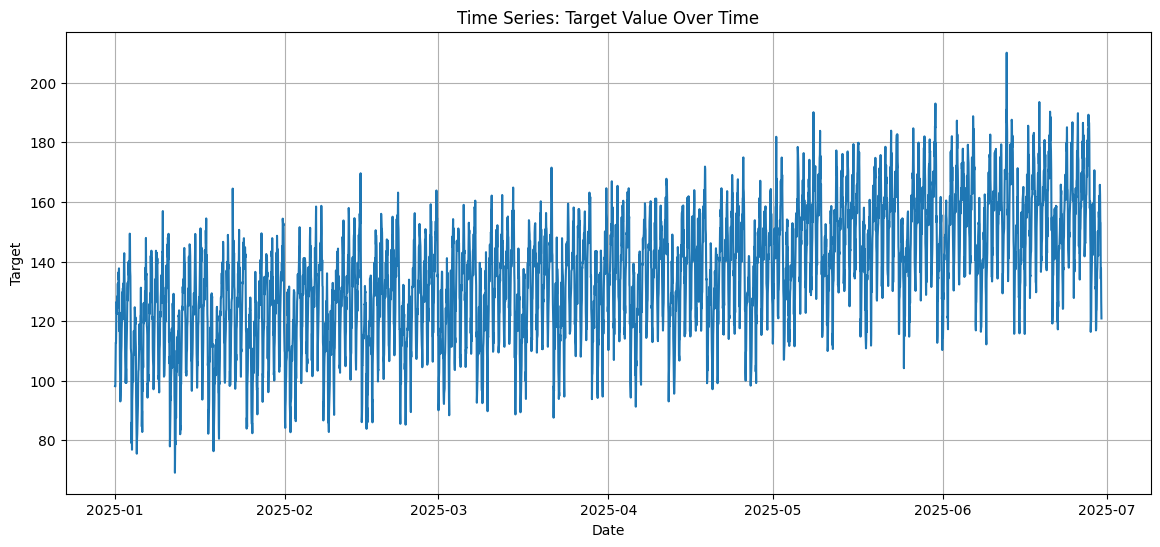

=== Time Series Characteristics ===
The series shows an upward trend with visible cyclical patterns.
No missing values to handle.


In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["target"])
plt.title("Time Series: Target Value Over Time")
plt.xlabel("Date")
plt.ylabel("Target")
plt.grid(True)
plt.savefig(os.path.join(FIGURES_PATH, "base_time_series_plot.png"), dpi=100)
plt.show()

print("=== Time Series Characteristics ===")
print("The series shows an upward trend with visible cyclical patterns.")
print("No missing values to handle.")

## 3. Корректный temporal split

In [5]:
TARGET_COL = "target"
DATE_COL = "date"

n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("=== Temporal Split ===")
print(f"Total observations: {n}")
print(f"Train: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/n*100:.1f}%)")
print(f"\nTrain dates: {train_df[DATE_COL].min()} to {train_df[DATE_COL].max()}")
print(f"Val dates: {val_df[DATE_COL].min()} to {val_df[DATE_COL].max()}")
print(f"Test dates: {test_df[DATE_COL].min()} to {test_df[DATE_COL].max()}")

=== Temporal Split ===
Total observations: 4320
Train: 3024 (70.0%)
Validation: 648 (15.0%)
Test: 648 (15.0%)

Train dates: 2025-01-01 00:00:00 to 2025-05-06 23:00:00
Val dates: 2025-05-07 00:00:00 to 2025-06-02 23:00:00
Test dates: 2025-06-03 00:00:00 to 2025-06-29 23:00:00


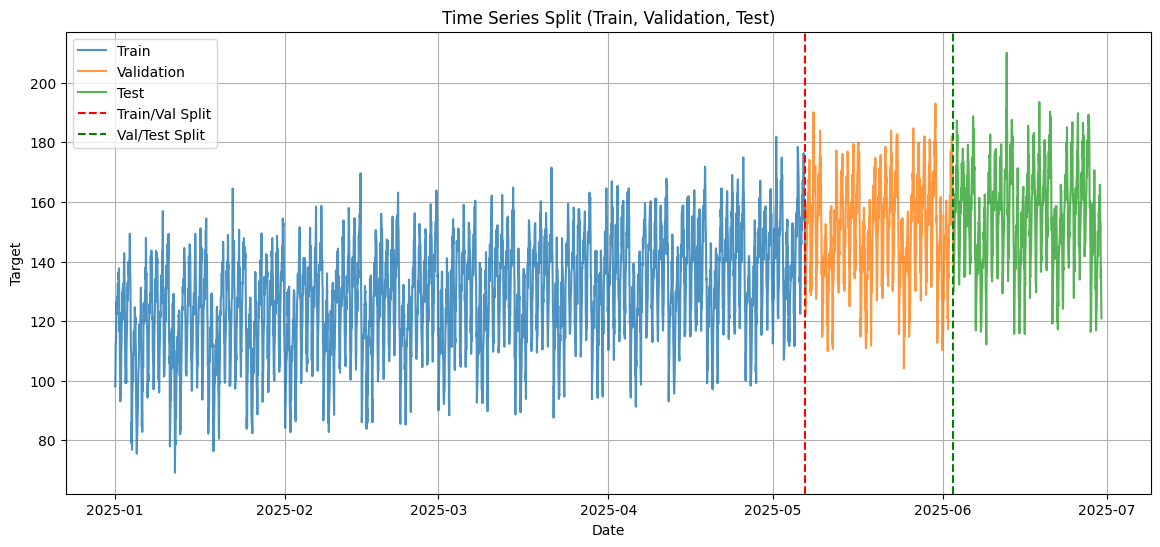


=== Why Temporal Split? ===
Random split is incorrect for time series - would leak future info.


In [6]:
plt.figure(figsize=(14, 6))
plt.plot(train_df[DATE_COL], train_df[TARGET_COL], label="Train", alpha=0.8)
plt.plot(val_df[DATE_COL], val_df[TARGET_COL], label="Validation", alpha=0.8)
plt.plot(test_df[DATE_COL], test_df[TARGET_COL], label="Test", alpha=0.8)
plt.axvline(x=train_df[DATE_COL].max(), color="r", linestyle="--", label="Train/Val Split")
plt.axvline(x=val_df[DATE_COL].max(), color="g", linestyle="--", label="Val/Test Split")
plt.title("Time Series Split (Train, Validation, Test)")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_PATH, "series_split.png"), dpi=100)
plt.show()

print("\n=== Why Temporal Split? ===")
print("Random split is incorrect for time series - would leak future info.")

## 4. Признаки для baseline-моделей

In [7]:
def create_features(data, fit_scaler=False, scaler=None):
    df_feat = data.copy()
    
    df_feat["lag_1"] = df_feat[TARGET_COL].shift(1)
    df_feat["lag_7"] = df_feat[TARGET_COL].shift(7)
    df_feat["lag_14"] = df_feat[TARGET_COL].shift(14)
    
    df_feat["rolling_mean_7"] = df_feat[TARGET_COL].rolling(window=7).mean().shift(1)
    df_feat["rolling_std_7"] = df_feat[TARGET_COL].rolling(window=7).std().shift(1)
    
    df_feat["day_of_week"] = df_feat[DATE_COL].dt.dayofweek
    df_feat["day_of_year"] = df_feat[DATE_COL].dt.dayofyear
    df_feat["month"] = df_feat[DATE_COL].dt.month
    df_feat["hour"] = df_feat[DATE_COL].dt.hour
    
    df_feat = df_feat.fillna(0)
    
    feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7",
                    "day_of_week", "day_of_year", "month", "hour"]
    
    if fit_scaler:
        scaler = StandardScaler()
        df_feat[feature_cols] = scaler.fit_transform(df_feat[feature_cols])
    elif scaler is not None:
        df_feat[feature_cols] = scaler.transform(df_feat[feature_cols])
    
    return df_feat, scaler, feature_cols

train_feat, scaler, feature_cols = create_features(train_df, fit_scaler=True)
val_feat, _, _ = create_features(val_df, fit_scaler=False, scaler=scaler)
test_feat, _, _ = create_features(test_df, fit_scaler=False, scaler=scaler)

print("=== Features Created ===")
print(f"Feature columns: {feature_cols}")

print("\n=== Preventing Data Leakage ===")
print("- Lag features use .shift(1) - only past values")
print("- Rolling features use .shift(1) - don't include current value")
print("- Scaler fitted only on train, applied to val/test")

=== Features Created ===
Feature columns: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'day_of_year', 'month', 'hour']

=== Preventing Data Leakage ===
- Lag features use .shift(1) - only past values
- Rolling features use .shift(1) - don't include current value
- Scaler fitted only on train, applied to val/test


## 5. Базовые эксперименты (B1, B2, B3)

In [8]:
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

In [9]:
# B1: Naive Last
print("=== B1: Naive Last ===")
train_values = train_df[TARGET_COL].values

val_b1_preds = []
for i in range(len(val_df)):
    if i == 0:
        val_b1_preds.append(train_values[-1])
    else:
        val_b1_preds.append(val_df[TARGET_COL].iloc[i-1])

test_b1_preds = []
for i in range(len(test_df)):
    if i == 0:
        test_b1_preds.append(val_df[TARGET_COL].iloc[-1])
    else:
        test_b1_preds.append(test_df[TARGET_COL].iloc[i-1])

val_mae_b1, val_rmse_b1, val_mape_b1 = calculate_metrics(val_df[TARGET_COL].values, val_b1_preds)
test_mae_b1, test_rmse_b1, test_mape_b1 = calculate_metrics(test_df[TARGET_COL].values, test_b1_preds)
print(f"Val MAE: {val_mae_b1:.4f}, RMSE: {val_rmse_b1:.4f}, MAPE: {val_mape_b1:.2f}%")
print(f"Test MAE: {test_mae_b1:.4f}, RMSE: {test_rmse_b1:.4f}, MAPE: {test_mape_b1:.2f}%")

=== B1: Naive Last ===
Val MAE: 6.4448, RMSE: 8.2010, MAPE: 4.40%
Test MAE: 6.3424, RMSE: 8.0591, MAPE: 4.15%


In [10]:
# B2: Moving Average
print("=== B2: Moving Average ===")
WINDOW = 7

def moving_average_forecast(series, window):
    preds = []
    for i in range(len(series)):
        if i < window:
            preds.append(series[:i+1].mean() if i > 0 else series[0])
        else:
            preds.append(series[i-window:i].mean())
    return np.array(preds)

val_b2_preds = moving_average_forecast(val_df[TARGET_COL].values, WINDOW)
test_b2_preds = moving_average_forecast(test_df[TARGET_COL].values, WINDOW)

val_mae_b2, val_rmse_b2, val_mape_b2 = calculate_metrics(val_df[TARGET_COL].values, val_b2_preds)
test_mae_b2, test_rmse_b2, test_mape_b2 = calculate_metrics(test_df[TARGET_COL].values, test_b2_preds)
print(f"Val MAE: {val_mae_b2:.4f}, RMSE: {val_rmse_b2:.4f}, MAPE: {val_mape_b2:.2f}%")
print(f"Test MAE: {test_mae_b2:.4f}, RMSE: {test_rmse_b2:.4f}, MAPE: {test_mape_b2:.2f}%")

=== B2: Moving Average ===
Val MAE: 12.6489, RMSE: 15.1756, MAPE: 8.77%
Test MAE: 12.6842, RMSE: 15.1939, MAPE: 8.51%


In [11]:
# B3: Ridge
print("=== B3: Ridge with Lag Features ===")

X_train = train_feat[feature_cols].values
y_train = train_feat[TARGET_COL].values
X_val = val_feat[feature_cols].values
y_val = val_feat[TARGET_COL].values
X_test = test_feat[feature_cols].values
y_test = test_feat[TARGET_COL].values

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

val_b3_preds = ridge.predict(X_val)
test_b3_preds = ridge.predict(X_test)

val_mae_b3, val_rmse_b3, val_mape_b3 = calculate_metrics(y_val, val_b3_preds)
test_mae_b3, test_rmse_b3, test_mape_b3 = calculate_metrics(y_test, test_b3_preds)
print(f"Val MAE: {val_mae_b3:.4f}, RMSE: {val_rmse_b3:.4f}, MAPE: {val_mape_b3:.2f}%")
print(f"Test MAE: {test_mae_b3:.4f}, RMSE: {test_rmse_b3:.4f}, MAPE: {test_mape_b3:.2f}%")

=== B3: Ridge with Lag Features ===
Val MAE: 6.0227, RMSE: 7.9983, MAPE: 4.08%
Test MAE: 5.7586, RMSE: 7.9131, MAPE: 3.74%


## 6. Оконное представление для GRU

In [12]:
WINDOW_SIZE = 24
HORIZON = 1
BATCH_SIZE = 32

class TimeSeriesWindowDataset(Dataset):
    def __init__(self, data, target, window_size):
        self.data = data
        self.target = target
        self.window_size = window_size
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.target[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]]).flatten()
y_val_scaled = target_scaler.transform(val_df[[TARGET_COL]]).flatten()
y_test_scaled = target_scaler.transform(test_df[[TARGET_COL]]).flatten()

X_train_feat = train_feat[feature_cols].values
X_val_feat = val_feat[feature_cols].values
X_test_feat = test_feat[feature_cols].values

input_scaler = StandardScaler()
X_train_scaled = input_scaler.fit_transform(X_train_feat)
X_val_scaled = input_scaler.transform(X_val_feat)
X_test_scaled = input_scaler.transform(X_test_feat)

train_dataset = TimeSeriesWindowDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesWindowDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesWindowDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=== GRU Dataset ===")
print(f"Window size: {WINDOW_SIZE}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

for x, y in train_loader:
    print(f"X shape: {x.shape}, y shape: {y.shape}")
    break

=== GRU Dataset ===
Window size: 24
Train samples: 3000
Val samples: 624
Test samples: 624
X shape: torch.Size([32, 24, 9]), y shape: torch.Size([32])


## 7. GRU модель и обучение

In [13]:
class GRUForecast(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

INPUT_SIZE = len(feature_cols)
HIDDEN_SIZE = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 15

model = GRUForecast(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

print("=== GRU Model ===")
print(f"Input size: {INPUT_SIZE}, Hidden: {HIDDEN_SIZE}, Layers: {NUM_LAYERS}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

=== GRU Model ===
Input size: 9, Hidden: 64, Layers: 2
Parameters: 39425


In [14]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out.squeeze(), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device, scaler):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x).squeeze().cpu().numpy()
            preds.extend(out)
            targets.extend(y.numpy())
    
    preds_unscaled = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    targets_unscaled = scaler.inverse_transform(np.array(targets).reshape(-1, 1)).flatten()
    
    mae, rmse, mape = calculate_metrics(targets_unscaled, preds_unscaled)
    return mae, rmse, mape, preds_unscaled, targets_unscaled

print("=== Training GRU ===")
history = defaultdict(list)
best_val_mae = float('inf')
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_mae, val_rmse, val_mape, _, _ = evaluate(model, val_loader, device, target_scaler)
    
    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_mape'].append(val_mape)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {train_loss:.4f} | Val MAE: {val_mae:.2f}, RMSE: {val_rmse:.2f}, MAPE: {val_mape:.2f}%")
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = model.state_dict().copy()

print(f"\nBest Val MAE: {best_val_mae:.2f}")

=== Training GRU ===
Epoch  1/15 | Loss: 0.3428 | Val MAE: 6.55, RMSE: 8.37, MAPE: 4.33%
Epoch  2/15 | Loss: 0.1278 | Val MAE: 5.09, RMSE: 6.74, MAPE: 3.46%
Epoch  3/15 | Loss: 0.1160 | Val MAE: 4.89, RMSE: 6.49, MAPE: 3.33%
Epoch  4/15 | Loss: 0.1104 | Val MAE: 4.84, RMSE: 6.37, MAPE: 3.28%
Epoch  5/15 | Loss: 0.1069 | Val MAE: 4.79, RMSE: 6.30, MAPE: 3.25%
Epoch  6/15 | Loss: 0.1041 | Val MAE: 4.76, RMSE: 6.33, MAPE: 3.21%
Epoch  7/15 | Loss: 0.1035 | Val MAE: 4.69, RMSE: 6.23, MAPE: 3.18%
Epoch  8/15 | Loss: 0.1006 | Val MAE: 4.70, RMSE: 6.24, MAPE: 3.18%
Epoch  9/15 | Loss: 0.0983 | Val MAE: 4.63, RMSE: 6.18, MAPE: 3.15%
Epoch 10/15 | Loss: 0.0978 | Val MAE: 4.61, RMSE: 6.16, MAPE: 3.13%
Epoch 11/15 | Loss: 0.0955 | Val MAE: 4.59, RMSE: 6.15, MAPE: 3.12%
Epoch 12/15 | Loss: 0.0922 | Val MAE: 4.57, RMSE: 6.15, MAPE: 3.09%
Epoch 13/15 | Loss: 0.0912 | Val MAE: 4.69, RMSE: 6.22, MAPE: 3.20%
Epoch 14/15 | Loss: 0.0854 | Val MAE: 4.62, RMSE: 6.08, MAPE: 3.14%
Epoch 15/15 | Loss: 0.0856 

In [15]:
model.load_state_dict(best_model_state)
test_mae_r1, test_rmse_r1, test_mape_r1, test_preds_r1, test_targets_r1 = evaluate(model, test_loader, device, target_scaler)
val_mae_r1 = best_val_mae
val_rmse_r1 = history['val_rmse'][-1]
val_mape_r1 = history['val_mape'][-1]

print("=== R1: GRU Results ===")
print(f"Val MAE: {val_mae_r1:.4f}, RMSE: {val_rmse_r1:.4f}, MAPE: {val_mape_r1:.2f}%")
print(f"Test MAE: {test_mae_r1:.4f}, RMSE: {test_rmse_r1:.4f}, MAPE: {test_mape_r1:.2f}%")

=== R1: GRU Results ===
Val MAE: 4.5700, RMSE: 6.8691, MAPE: 3.36%
Test MAE: 4.9749, RMSE: 6.6246, MAPE: 3.26%


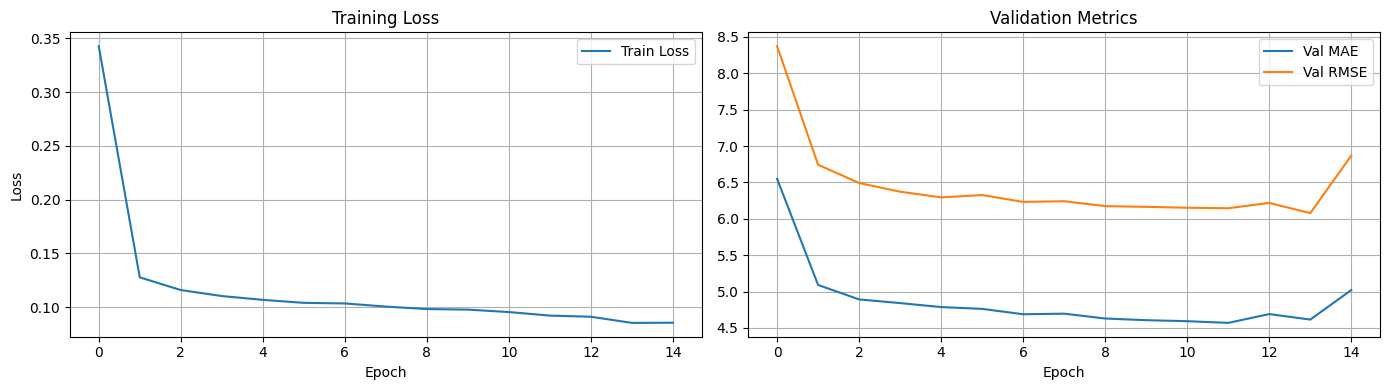

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['val_mae'], label='Val MAE')
axes[1].plot(history['val_rmse'], label='Val RMSE')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "gru_learning_curves.png"), dpi=100)
plt.show()

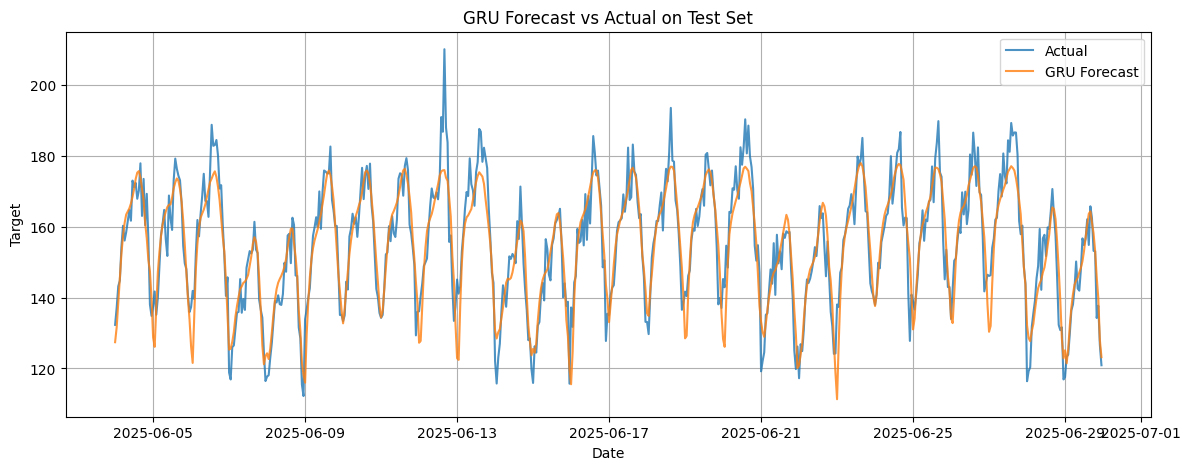

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(test_df[DATE_COL].values[WINDOW_SIZE:], test_targets_r1, label='Actual', alpha=0.8)
plt.plot(test_df[DATE_COL].values[WINDOW_SIZE:], test_preds_r1, label='GRU Forecast', alpha=0.8)
plt.title('GRU Forecast vs Actual on Test Set')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_PATH, "best_forecast_test.png"), dpi=100)
plt.show()

## 8. Сравнение всех подходов

In [18]:
results_df = pd.DataFrame({
    'Experiment': ['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)'],
    'Val_MAE': [val_mae_b1, val_mae_b2, val_mae_b3, val_mae_r1],
    'Val_RMSE': [val_rmse_b1, val_rmse_b2, val_rmse_b3, val_rmse_r1],
    'Val_MAPE': [val_mape_b1, val_mape_b2, val_mape_b3, val_mape_r1],
    'Test_MAE': [test_mae_b1, test_mae_b2, test_mae_b3, test_mae_r1],
    'Test_RMSE': [test_rmse_b1, test_rmse_b2, test_rmse_b3, test_rmse_r1],
    'Test_MAPE': [test_mape_b1, test_mape_b2, test_mape_b3, test_mape_r1]
})

print("=== Results Comparison ===")
print(results_df.to_string(index=False))

=== Results Comparison ===
Experiment   Val_MAE  Val_RMSE  Val_MAPE  Test_MAE  Test_RMSE  Test_MAPE
B1 (Naive)  6.444815  8.201023  4.397922  6.342438   8.059069   4.148548
   B2 (MA) 12.648900 15.175574  8.774798 12.684155  15.193940   8.507565
B3 (Ridge)  6.022728  7.998291  4.077118  5.758554   7.913139   3.744253
  R1 (GRU)  4.570037  6.869131  3.363699  4.974894   6.624610   3.262337


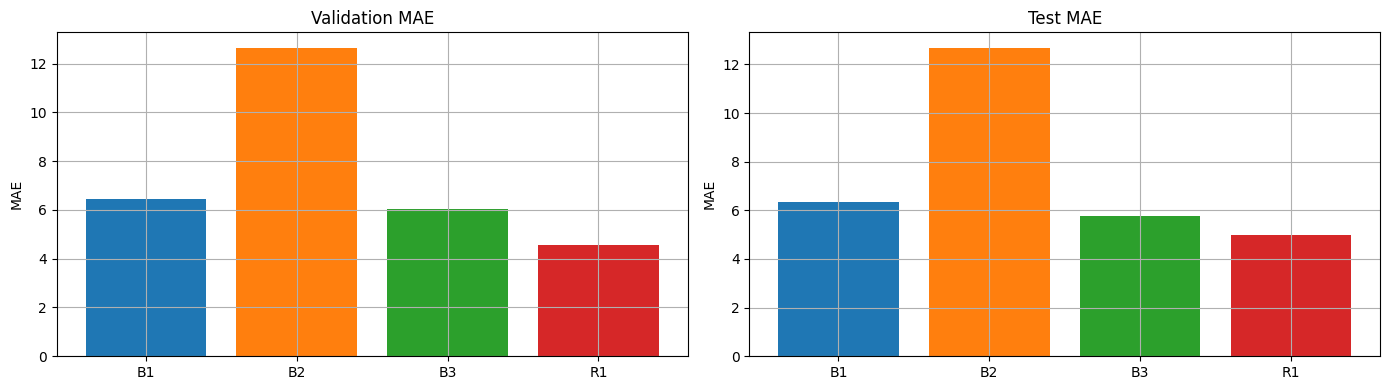

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = range(4)
labels = ['B1', 'B2', 'B3', 'R1']

axes[0].bar(x, results_df['Val_MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Validation MAE')
axes[0].set_ylabel('MAE')
axes[0].grid(True, axis='y')

axes[1].bar(x, results_df['Test_MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Test MAE')
axes[1].set_ylabel('MAE')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "baselines_compare.png"), dpi=100)
plt.show()

## 9. Сохранение артефактов

In [20]:
runs_data = [
    {
        'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED,
        'split_summary': f'Train:{len(train_df)}, Val:{len(val_df)}, Test:{len(test_df)}',
        'window_size': None, 'horizon': 1, 'model_summary': 'naive-last', 'features_summary': 'last_value',
        'scaler': None, 'optimizer': None, 'lr': None, 'epochs_trained': 0,
        'best_val_mae': val_mae_b1, 'best_val_rmse': val_rmse_b1, 'best_val_mape': val_mape_b1,
        'test_mae': test_mae_b1, 'test_rmse': test_rmse_b1, 'test_mape': test_mape_b1,
        'notes': 'Baseline: predict last known value'
    },
    {
        'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED,
        'split_summary': f'Train:{len(train_df)}, Val:{len(val_df)}, Test:{len(test_df)}',
        'window_size': None, 'horizon': 1, 'model_summary': 'moving-average-7', 'features_summary': 'rolling_mean_7',
        'scaler': None, 'optimizer': None, 'lr': None, 'epochs_trained': 0,
        'best_val_mae': val_mae_b2, 'best_val_rmse': val_rmse_b2, 'best_val_mape': val_mape_b2,
        'test_mae': test_mae_b2, 'test_rmse': test_rmse_b2, 'test_mape': test_mape_b2,
        'notes': 'Baseline: 7-point moving average'
    },
    {
        'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED,
        'split_summary': f'Train:{len(train_df)}, Val:{len(val_df)}, Test:{len(test_df)}',
        'window_size': None, 'horizon': 1, 'model_summary': 'Ridge',
        'features_summary': 'lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,day_of_year,month,hour',
        'scaler': 'StandardScaler', 'optimizer': None, 'lr': None, 'epochs_trained': 0,
        'best_val_mae': val_mae_b3, 'best_val_rmse': val_rmse_b3, 'best_val_mape': val_mape_b3,
        'test_mae': test_mae_b3, 'test_rmse': test_rmse_b3, 'test_mape': test_mape_b3,
        'notes': 'Ridge regression with lag/rolling/calendar features'
    },
    {
        'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED,
        'split_summary': f'Train:{len(train_df)}, Val:{len(val_df)}, Test:{len(test_df)}',
        'window_size': WINDOW_SIZE, 'horizon': 1,
        'model_summary': f'GRU(hidden={HIDDEN_SIZE},layers={NUM_LAYERS})',
        'features_summary': 'lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,day_of_year,month,hour',
        'scaler': 'StandardScaler', 'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS,
        'best_val_mae': val_mae_r1, 'best_val_rmse': val_rmse_r1, 'best_val_mape': val_mape_r1,
        'test_mae': test_mae_r1, 'test_rmse': test_rmse_r1, 'test_mape': test_mape_r1,
        'notes': 'GRU with 24-hour window, best model by val MAE'
    }
]

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv(os.path.join(ARTIFACTS_PATH, "runs.csv"), index=False)
print("Saved: runs.csv")

torch.save(best_model_state, os.path.join(ARTIFACTS_PATH, "best_gru.pt"))
print("Saved: best_gru.pt")

gru_config = {
    'dataset': 'S12-hw-dataset.csv',
    'model_summary': f'GRU(hidden={HIDDEN_SIZE},layers={NUM_LAYERS})',
    'window_size': WINDOW_SIZE, 'horizon': HORIZON,
    'input_size': INPUT_SIZE, 'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
    'batch_size': BATCH_SIZE, 'scaler': 'StandardScaler',
    'optimizer': 'Adam', 'lr': LR, 'epochs_trained': EPOCHS, 'seed': SEED,
    'best_val_mae': float(val_mae_r1), 'feature_cols': feature_cols
}
with open(os.path.join(ARTIFACTS_PATH, "best_gru_config.json"), 'w') as f:
    json.dump(gru_config, f, indent=2)
print("Saved: best_gru_config.json")

print("\nAll artifacts saved successfully!")
print(f"\n=== FINAL RESULTS ===")
print(f"Best model: R1 (GRU)")
print(f"Val MAE: {val_mae_r1:.2f}, Test MAE: {test_mae_r1:.2f}")

Saved: runs.csv
Saved: best_gru.pt
Saved: best_gru_config.json

All artifacts saved successfully!

=== FINAL RESULTS ===
Best model: R1 (GRU)
Val MAE: 4.57, Test MAE: 4.97
